# 04 — Evaluación generativa (t-SNE, marginales, clasificador)

Evalúa ventanas sintéticas frente a:

- **`donor_validation`** — reales ocultos (split principal de validación)
- **`donor_train`** — datos con los que se entrenó la GAN (sanity check)

**No usar NVDA visible/test para tunear la GAN.**

| Métrica | Interpretación |
|---|---|
| Marginales similares | Distribución univariada parecida |
| t-SNE mezclado | Estructura global similar |
| Clasificador AUC ≈ 0.5 | Difícil distinguir real vs sintético → buena generación |

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.data import CHANNELS, load_donor_windows, windows_to_array
from src.metrics import channel_summary, temporal_autocorr_report
from src.paths import default_windows_dir, outputs_dir

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(42)

I0000 00:00:1788085268.800385  721099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788085268.800761  721099 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788085268.829893  721099 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788085269.510757  721099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
# --- Configuración ---
SYNTHETIC_PATH = sorted(outputs_dir().glob("synthetic_*.parquet"))[-1]
TSNE_PERPLEXITY = 30
TSNE_SAMPLES_PER_GROUP = 400   # submuestreo para t-SNE estable
CV_FOLDS = 5

synthetic = pd.read_parquet(SYNTHETIC_PATH)
validation = load_donor_windows("donor_validation", windows_dir=default_windows_dir())
train = load_donor_windows("donor_train", windows_dir=default_windows_dir())

X_syn = windows_to_array(synthetic)
X_val = windows_to_array(validation)
X_train = windows_to_array(train)

print(f"Sintético : {SYNTHETIC_PATH.name}  n={len(X_syn)}")
print(f"Validation (ocultos): n={len(X_val)}")
print(f"Train (donors)      : n={len(X_train)}")

Sintético : synthetic_seed42_ratio0.25.parquet  n=50
Validation (ocultos): n=380
Train (donors)      : n=4910


## 1. Marginales — distribuciones por canal

Comparamos histogramas/KDE de cada canal (todos los timesteps apilados) y estadísticas resumidas.

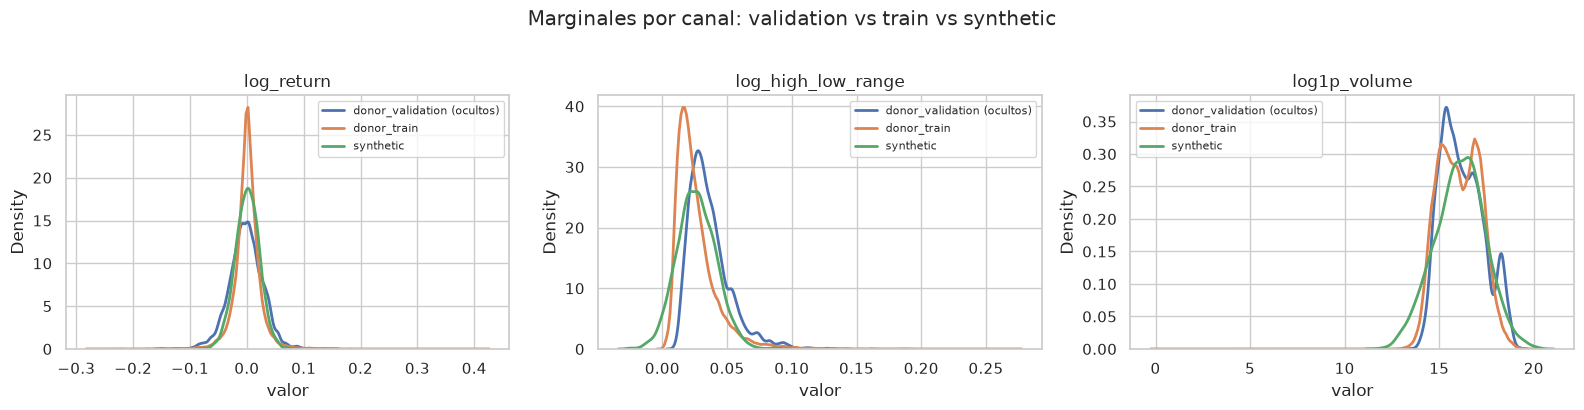

In [3]:
def flatten_channel(windows: np.ndarray, channel_idx: int) -> np.ndarray:
    return windows[:, :, channel_idx].reshape(-1)


sources = {
    "donor_validation (ocultos)": X_val,
    "donor_train": X_train,
    "synthetic": X_syn,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, ch_idx, name in zip(axes, range(3), CHANNELS):
    for label, arr in sources.items():
        values = flatten_channel(arr, ch_idx)
        sns.kdeplot(values, ax=ax, label=label, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("valor")
    ax.legend(fontsize=8)
plt.suptitle("Marginales por canal: validation vs train vs synthetic", y=1.02)
plt.tight_layout()

In [4]:
summary_rows = []
for label, arr in sources.items():
    stats = channel_summary(arr)
    stats.insert(0, "source", label)
    summary_rows.append(stats)
summary_table = pd.concat(summary_rows, ignore_index=True)
display(summary_table)

autocorr_rows = []
for label, arr in sources.items():
    ac = temporal_autocorr_report(arr)
    ac.insert(0, "source", label)
    autocorr_rows.append(ac)
autocorr_table = pd.concat(autocorr_rows, ignore_index=True)
print("Autocorrelación lag-1 (dependencia temporal):")
display(autocorr_table)

,source,channel,mean,std,min,max
0,donor_validation (ocultos),log_return,-0.001630,0.029279,-0.149299,0.149978
1,donor_validation (ocultos),log_high_low_range,0.036210,0.015943,0.009586,0.128724
2,donor_validation (ocultos),log1p_volume,16.219625,1.115950,13.508171,19.233361
3,donor_train,log_return,0.000811,0.023516,-0.277456,0.420617
4,donor_train,log_high_low_range,0.026026,0.016724,0.000000,0.273457
5,donor_train,log1p_volume,16.060272,1.093325,0.000000,20.143947
6,synthetic,log_return,0.000810,0.021097,-0.076646,0.080532
7,synthetic,log_high_low_range,0.026418,0.015061,-0.025103,0.090346
8,synthetic,log1p_volume,16.094977,1.330002,11.887916,20.268793


Autocorrelación lag-1 (dependencia temporal):


,source,channel,autocorr_lag1_mean,autocorr_lag1_std
0,donor_validation (ocultos),log_return,-0.058412,0.099225
1,donor_validation (ocultos),log_high_low_range,0.072556,0.096640
2,donor_validation (ocultos),log1p_volume,0.362559,0.152487
3,donor_train,log_return,-0.042547,0.145960
4,donor_train,log_high_low_range,0.252291,0.175862
5,donor_train,log1p_volume,0.462904,0.143563
6,synthetic,log_return,-0.037634,0.108101
7,synthetic,log_high_low_range,0.256948,0.160915
8,synthetic,log1p_volume,0.252352,0.157482


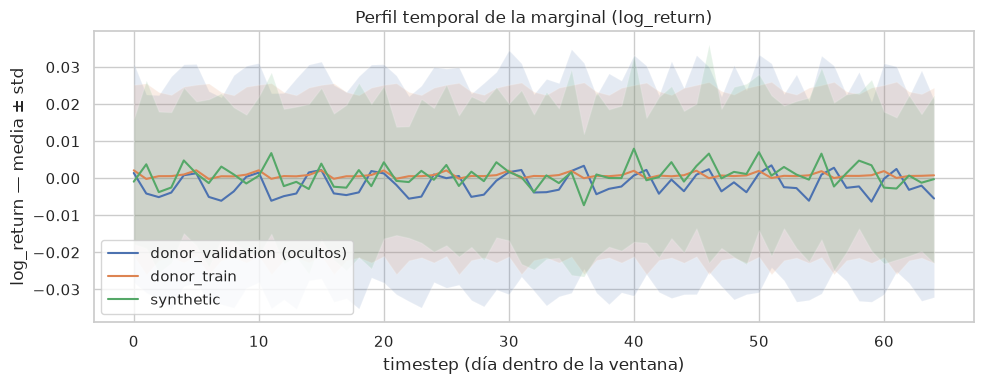

In [5]:
# Marginal por timestep (media en cada día t) — canal log_return
ch_idx = 0
fig, ax = plt.subplots(figsize=(10, 4))
for label, arr in sources.items():
    mean_t = arr[:, :, ch_idx].mean(axis=0)
    std_t = arr[:, :, ch_idx].std(axis=0)
    t = np.arange(arr.shape[1])
    ax.plot(t, mean_t, label=label)
    ax.fill_between(t, mean_t - std_t, mean_t + std_t, alpha=0.15)
ax.set_xlabel("timestep (día dentro de la ventana)")
ax.set_ylabel(f"{CHANNELS[ch_idx]} — media ± std")
ax.set_title("Perfil temporal de la marginal (log_return)")
ax.legend()
plt.tight_layout()

## 2. t-SNE — visualización de mezcla en el espacio de ventanas

Ventanas aplanadas (195 dims) → PCA (50) → t-SNE (2D). Submuestreo equilibrado por grupo.

In [6]:
def subsample_windows(windows: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    n = min(n, len(windows))
    idx = rng.choice(len(windows), size=n, replace=False)
    return windows[idx]


def prepare_embedding_sets(
    groups: dict[str, np.ndarray],
    n_per_group: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    arrays = []
    labels = []
    for name, windows in groups.items():
        sample = subsample_windows(windows, n_per_group, rng)
        arrays.append(sample.reshape(len(sample), -1))
        labels.extend([name] * len(sample))
    return np.vstack(arrays), np.asarray(labels)


embed_groups = {
    "donor_validation": X_val,
    "donor_train": X_train,
    "synthetic": X_syn,
}
X_embed, y_embed = prepare_embedding_sets(embed_groups, TSNE_SAMPLES_PER_GROUP, RNG)
print(X_embed.shape, np.unique(y_embed, return_counts=True))

(830, 195) (array(['donor_train', 'donor_validation', 'synthetic'], dtype='<U16'), array([400, 380,  50]))


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embed)

pca = PCA(n_components=min(50, X_scaled.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada PCA (50 comp): {pca.explained_variance_ratio_.sum():.2%}")

perplexity = min(TSNE_PERPLEXITY, max(5, len(X_pca) // 10))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
X_tsne = tsne.fit_transform(X_pca)

embed_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "source": y_embed,
})

Varianza explicada PCA (50 comp): 81.95%


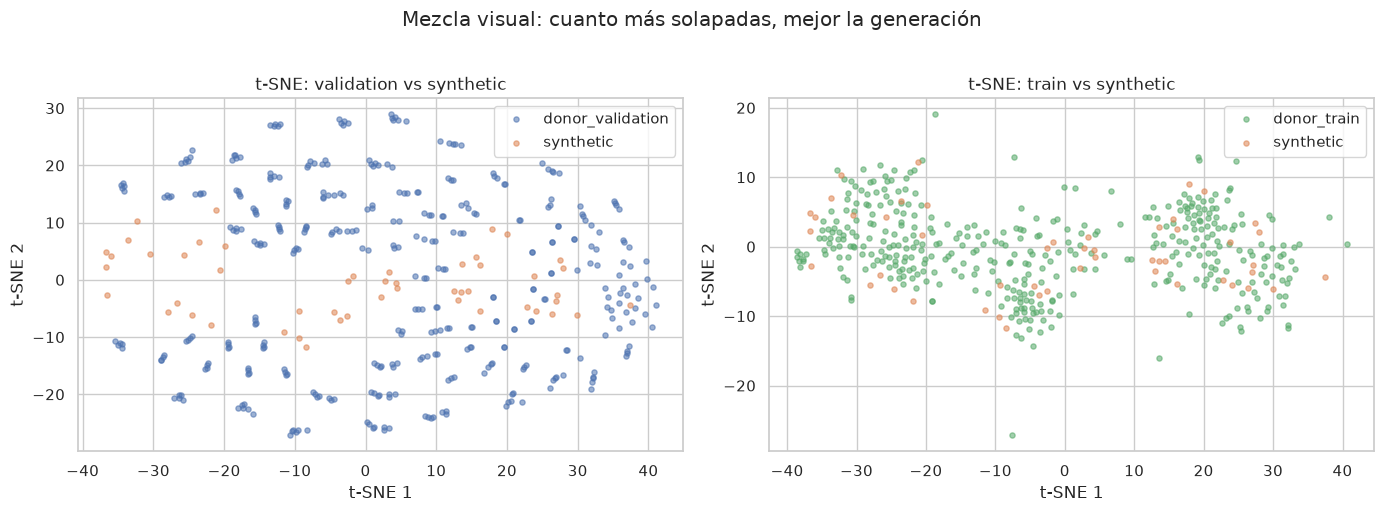

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {
    "donor_validation": "C0",
    "donor_train": "C2",
    "synthetic": "C1",
}

for ax, title, subset in [
    (axes[0], "t-SNE: validation vs synthetic", ["donor_validation", "synthetic"]),
    (axes[1], "t-SNE: train vs synthetic", ["donor_train", "synthetic"]),
]:
    mask = embed_df["source"].isin(subset)
    for src in subset:
        m = embed_df["source"].eq(src) & mask
        ax.scatter(
            embed_df.loc[m, "x"],
            embed_df.loc[m, "y"],
            s=14,
            alpha=0.55,
            label=src,
            c=palette[src],
        )
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("Mezcla visual: cuanto más solapadas, mejor la generación", y=1.02)
plt.tight_layout()

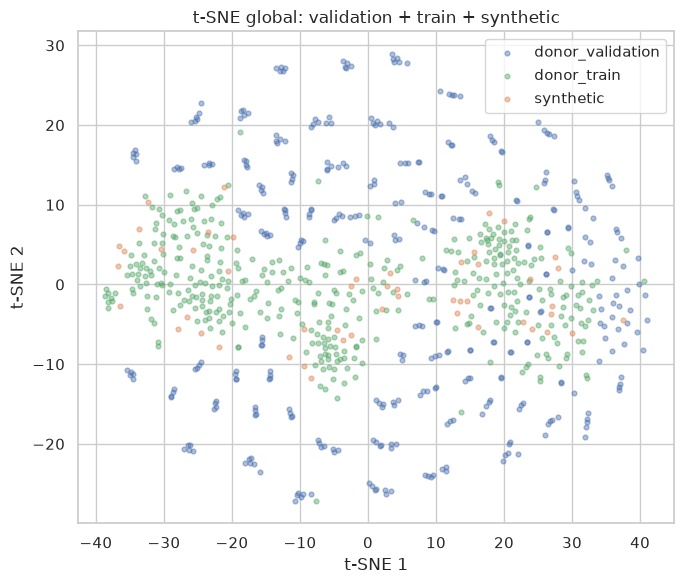

In [9]:
# Vista global: los tres grupos juntos
plt.figure(figsize=(7, 6))
for src, color in palette.items():
    m = embed_df["source"].eq(src)
    plt.scatter(embed_df.loc[m, "x"], embed_df.loc[m, "y"], s=12, alpha=0.45, label=src, c=color)
plt.legend()
plt.title("t-SNE global: validation + train + synthetic")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()

## 3. Clasificador — regresión logística (C2ST)

Etiqueta 0 = real, 1 = sintético. **AUC ≈ 0.5** → indistinguibles (bueno). **AUC → 1** → fácil detectar fakes (malo).

Evaluación principal: **`donor_validation` vs synthetic**.

In [10]:
def run_classifier_two_sample_test(
    real_windows: np.ndarray,
    synthetic_windows: np.ndarray,
    *,
    real_label: str,
    cv_folds: int = 5,
    random_state: int = 42,
) -> dict:
    n = min(len(real_windows), len(synthetic_windows))
    rng = np.random.default_rng(random_state)
    real_idx = rng.choice(len(real_windows), size=n, replace=False)
    syn_idx = rng.choice(len(synthetic_windows), size=n, replace=False)

    X = np.vstack([
        real_windows[real_idx].reshape(n, -1),
        synthetic_windows[syn_idx].reshape(n, -1),
    ])
    y = np.array([0] * n + [1] * n)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, C=1.0, random_state=random_state)),
    ])

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    auc_scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
    acc_scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = clf.predict(X_te)

    return {
        "comparison": f"{real_label} (0) vs synthetic (1)",
        "n_per_class": n,
        "auc_cv_mean": float(auc_scores.mean()),
        "auc_cv_std": float(auc_scores.std()),
        "acc_cv_mean": float(acc_scores.mean()),
        "acc_cv_std": float(acc_scores.std()),
        "holdout_auc": float(roc_auc_score(y_te, y_prob)),
        "holdout_acc": float(accuracy_score(y_te, y_pred)),
        "holdout_report": classification_report(y_te, y_pred, target_names=["real", "synthetic"]),
        "fitted_model": clf,
        "X_test": X_te,
        "y_test": y_te,
        "y_prob": y_prob,
    }

In [11]:
result_val = run_classifier_two_sample_test(
    X_val, X_syn, real_label="donor_validation", cv_folds=CV_FOLDS
)
result_train = run_classifier_two_sample_test(
    X_train, X_syn, real_label="donor_train", cv_folds=CV_FOLDS
)

for result in [result_val, result_train]:
    print("=" * 60)
    print(result["comparison"])
    print(f"AUC CV : {result['auc_cv_mean']:.3f} ± {result['auc_cv_std']:.3f}")
    print(f"Acc CV : {result['acc_cv_mean']:.3f} ± {result['acc_cv_std']:.3f}")
    print(f"Holdout AUC: {result['holdout_auc']:.3f}  Acc: {result['holdout_acc']:.3f}")
    print(result["holdout_report"])

donor_validation (0) vs synthetic (1)
AUC CV : 0.838 ± 0.040
Acc CV : 0.750 ± 0.071
Holdout AUC: 0.667  Acc: 0.680
              precision    recall  f1-score   support

        real       0.67      0.77      0.71        13
   synthetic       0.70      0.58      0.64        12

    accuracy                           0.68        25
   macro avg       0.68      0.68      0.68        25
weighted avg       0.68      0.68      0.68        25

donor_train (0) vs synthetic (1)
AUC CV : 0.602 ± 0.122
Acc CV : 0.570 ± 0.129
Holdout AUC: 0.404  Acc: 0.440
              precision    recall  f1-score   support

        real       0.47      0.54      0.50        13
   synthetic       0.40      0.33      0.36        12

    accuracy                           0.44        25
   macro avg       0.43      0.44      0.43        25
weighted avg       0.43      0.44      0.43        25



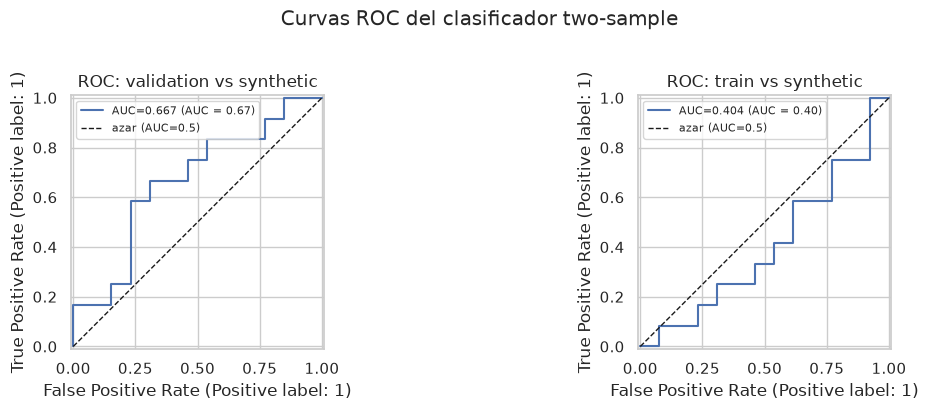

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, result, title in [
    (axes[0], result_val, "ROC: validation vs synthetic"),
    (axes[1], result_train, "ROC: train vs synthetic"),
]:
    RocCurveDisplay.from_predictions(
        result["y_test"],
        result["y_prob"],
        ax=ax,
        name=f"AUC={result['holdout_auc']:.3f}",
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="azar (AUC=0.5)")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Curvas ROC del clasificador two-sample", y=1.02)
plt.tight_layout()

## Resumen ejecutivo

In [13]:
def quality_verdict(auc: float) -> str:
    dist = abs(auc - 0.5)
    if dist < 0.05:
        return "excelente (casi indistinguible)"
    if dist < 0.10:
        return "bueno"
    if dist < 0.20:
        return "moderado (hay señales detectables)"
    return "débil (fácil distinguir real vs sintético)"


exec_summary = pd.DataFrame([
    {
        "comparación": "validation vs synthetic (principal)",
        "AUC_CV": result_val["auc_cv_mean"],
        "veredicto": quality_verdict(result_val["auc_cv_mean"]),
    },
    {
        "comparación": "train vs synthetic (sanity)",
        "AUC_CV": result_train["auc_cv_mean"],
        "veredicto": quality_verdict(result_train["auc_cv_mean"]),
    },
])
display(exec_summary)

report_path = SYNTHETIC_PATH.with_suffix(".eval_generative.json")
payload = {
    "synthetic_path": str(SYNTHETIC_PATH),
    "classifier_validation_vs_synthetic": {
        k: v for k, v in result_val.items()
        if k not in {"fitted_model", "X_test", "y_test", "y_prob", "holdout_report"}
    },
    "classifier_train_vs_synthetic": {
        k: v for k, v in result_train.items()
        if k not in {"fitted_model", "X_test", "y_test", "y_prob", "holdout_report"}
    },
    "channel_summary": summary_table.to_dict(orient="records"),
    "autocorr_summary": autocorr_table.to_dict(orient="records"),
}
report_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Informe guardado en {report_path}")

,comparación,AUC_CV,veredicto
0,validation vs synthetic (principal),0.838,débil (fácil distinguir real vs sintético)
1,train vs synthetic (sanity),0.602,moderado (hay señales detectables)


Informe guardado en /home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian/generadores/cristian/outputs/synthetic_seed42_ratio0.25.eval_generative.json
